## CNN + Transformer + CTC Loss


In [1]:
import math
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from matplotlib import pyplot as plt
import jiwer

## Load training and validation data

In [2]:
train_csv_path = Path('train.csv')
val_csv_path = Path('test1.csv')

IMG_H = 64
IMG_W = 200

train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
# build vocabulary from training labels so we count all letters are there 
# index 0 is reserved for CTC blank token
vocab = {}
idx = 1
all_labels = train_df['label'].tolist() + val_df['label'].tolist()
for label in all_labels:
    for char in str(label):
        if char not in vocab:
            vocab[char] = idx
            idx += 1

# reverse vocab: from numbers to text for prediction
inv_vocab = {}
for char, i in vocab.items():
    inv_vocab[i] = char
inv_vocab[0] = ''  # blank token

num_classes = len(vocab) + 1  # +1 for CTC blank

# find the longest label 
max_label_len = 0
for label in train_df['label'].tolist():
    if len(str(label)) > max_label_len:
        max_label_len = len(str(label))

print(f'Vocab: {vocab}')
print(f'Vocab size: {len(vocab)}')
print(f'Num classes: {num_classes}')
print(f'Max label length: {max_label_len}')

Vocab: {'1': 1, '0': 2, '8': 3, 'R': 4, '2': 5, '5': 6, 'W': 7, '4': 8, 'S': 9, '6': 10, '3': 11, 'D': 12, 'M': 13, '9': 14, 'A': 15, 'B': 16, 'H': 17, '7': 18, 'Y': 19, 'T': 20, 'K': 21}
Vocab size: 21
Num classes: 22
Max label length: 7


In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


### see sample data

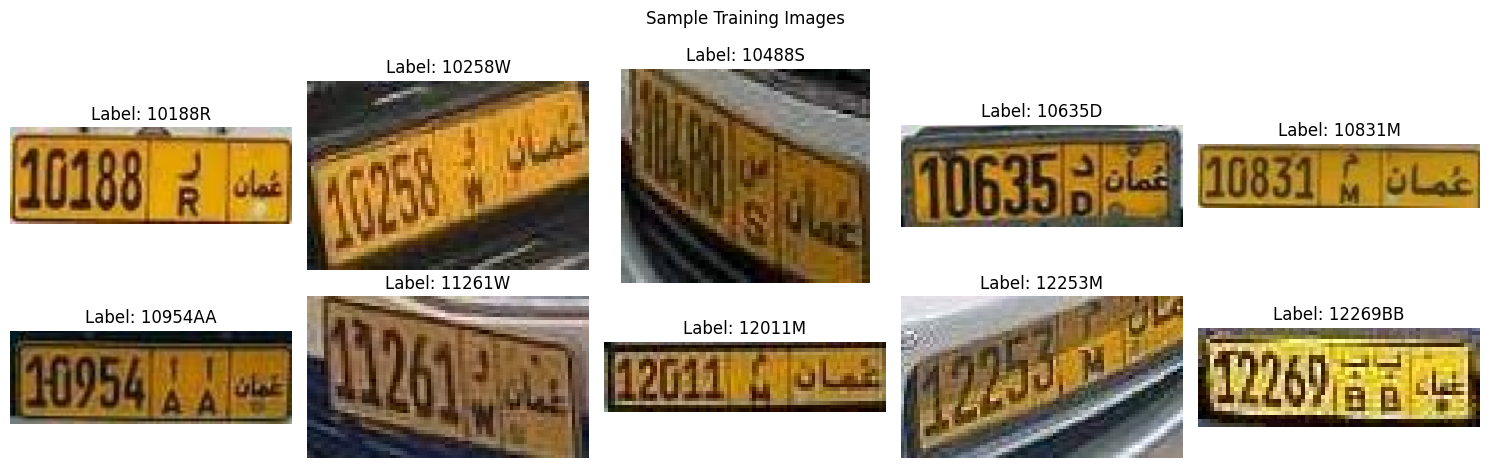

In [4]:
# show some sample images from the training set
figure, ax = plt.subplots(2, 5, figsize=(15, 5))

for i in range(10):
    row = train_df.iloc[i]
    img = Image.open(Path('.') / row['image_path']).convert('RGB')
    ax[i//5, i%5].imshow(img)
    ax[i//5, i%5].set_title(f'Label: {row["label"]}')
    ax[i//5, i%5].axis('off')

plt.suptitle('Sample Training Images')
plt.tight_layout()
plt.show()

### check if we need to resize or not 

In [5]:
# check if images have different sizes
print('Image sizes in training set:')
sizes = []
for i in range(len(train_df)):
    img = Image.open(Path('.') / train_df.iloc[i]['image_path'])
    sizes.append(img.size)

unique_sizes = set(sizes)
print(f'Number of unique sizes: {len(unique_sizes)}')
print(f'Min width : {min(s[0] for s in sizes)}')
print(f'Max width : {max(s[0] for s in sizes)}')
print(f'Min height: {min(s[1] for s in sizes)}')
print(f'Max height: {max(s[1] for s in sizes)}')

Image sizes in training set:
Number of unique sizes: 296
Min width : 47
Max width : 620
Min height: 15
Max height: 313


## Dataset

We apply augmentation on training images to improve generalization since we only have 300 training images. Validation images are only resized and normalized without any augmentation to get consistent evaluation results.

In [ ]:
#Augmentation for train
train_transform = transforms.Compose([
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3),
    transforms.RandomAffine(degrees=3, translate=(0.05, 0.03)),
    transforms.GaussianBlur(kernel_size=3),
    transforms.RandomEqualize(p=0.3),       ### part2 for black 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]), # -1,1
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]), 
])


class PlateDataset(Dataset):
    def __init__(self, csv_path, vocab, transform):  # how we load one image from csv to memory
        self.df = pd.read_csv(csv_path)
        self.vocab = vocab
        self.transform = transform

    def __len__(self):         # how many image in the dataset
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = str(row['label'])

        image = Image.open(Path('.') / row['image_path']).convert('RGB')
        image = self.transform(image)

        # convert each character to its index number
        label_indices = []
        for char in label:
            label_indices.append(self.vocab[char])
        label_tensor = torch.tensor(label_indices, dtype=torch.long)

        return image, label_tensor, len(label_indices), label, str(row['image_path'])


def ctc_collate_fn(batch):
    images, labels, label_lengths, label_strs, paths = zip(*batch)
    images = torch.stack(images)
    targets = torch.cat(labels)
    target_lengths = torch.tensor(label_lengths, dtype=torch.long)
    return images, targets, target_lengths, label_strs, paths


train_ds = PlateDataset(train_csv_path, vocab, train_transform)
val_ds = PlateDataset(val_csv_path, vocab, val_transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0, collate_fn=ctc_collate_fn)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0, collate_fn=ctc_collate_fn)

print(f'Train samples: {len(train_ds)}')
print(f'Val samples: {len(val_ds)}')

Train samples: 313
Val samples: 296


## Model Architecture

### CNN Backbone
CNN produces a feature map of shape (B, 512, 1, 50).

The CNN backbone extracts visual features from the plate image and converts it into a sequence of 50 feature columns. We use a custom CNN built from scratch with 5 stages. Each stage applies convolution followed by pooling to reduce the height of the feature map.

From stage 3 onward we use asymmetric pooling (2,1) which reduces only the height and not the width. This is important because the width dimension represents the number of time steps given to the Transformer — we need to keep it at 50 so CTC has enough room to align the characters. By the final stage the height is collapsed to 1 and each of the 50 columns is described by 512 feature values.

In [7]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x


class CNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()

        # stage 1: (B, 3, 64, 200) -> (B, 64, 32, 100)
        self.stage1 = nn.Sequential(
            ConvBNReLU(3, 64),
            nn.MaxPool2d(2, 2)
        )
        # stage 2: (B, 64, 32, 100) -> (B, 128, 16, 50)
        self.stage2 = nn.Sequential(
            ConvBNReLU(64, 128),
            nn.MaxPool2d(2, 2)
        )
        # stage 3: (B, 128, 16, 50) -> (B, 256, 8, 50)
        self.stage3 = nn.Sequential(
            ConvBNReLU(128, 256),
            ConvBNReLU(256, 256),
            nn.MaxPool2d((2, 1), (2, 1))
        )
        # stage 4: (B, 256, 8, 50) -> (B, 256, 4, 50)
        self.stage4 = nn.Sequential(
            ConvBNReLU(256, 256),
            nn.MaxPool2d((2, 1), (2, 1))
        )
        # stage 5: (B, 256, 4, 50) -> (B, 256, 1, 50)
        self.stage5 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=(4, 1), bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 50))

    def forward(self, x):
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.stage5(x)
        x = self.adaptive_pool(x)
        return x


# test the CNN
cnn_test = CNNBackbone()
dummy = torch.zeros(2, 3, IMG_H, IMG_W)
out = cnn_test(dummy)
print(f'CNN output shape: {out.shape}')  # should be (2, 256, 1, 50)

CNN output shape: torch.Size([2, 256, 1, 50])


### Positional Encoding
The Transformer processes all 50 columns at the same time which means it does not know the order of the input. Without positional encoding column 1 and column 50 look the same to the model. We fix this by adding a unique pattern of sine and cosine values to each column so the model can tell positions apart.

This is the original positional encoding formula from Vaswani et al. (2017) "Attention Is All You Need".

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # build the positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)  # even indices
        pe[:, 1::2] = torch.cos(position * div_term)  # odd indices
        pe = pe.unsqueeze(1)  # (max_len, 1, d_model)

        # register as buffer so it is saved with the model but not trained
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (T, B, d_model)
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

### Multi-Head Self-Attention
For each position in the sequence we compute Query, Key and Value vectors. The attention score between two positions is the dot product of their Query and Key divided by the square root of the head dimension. This gives a weight for how much each position should attend to every other position.

We use 8 heads running in parallel. Each head learns to focus on different aspects — for example one head might focus on digit patterns while another focuses on letter positions.

In [9]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_out = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        T, B, d = x.shape

        # project to Q, K, V
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        # split into multiple heads: (T, B, d_model) -> (B, heads, T, d_head)
        Q = Q.view(T, B, self.num_heads, self.d_head).permute(1, 2, 0, 3)
        K = K.view(T, B, self.num_heads, self.d_head).permute(1, 2, 0, 3)
        V = V.view(T, B, self.num_heads, self.d_head).permute(1, 2, 0, 3)

        # scaled dot-product attention
        scale = math.sqrt(self.d_head)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / scale
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        # weighted sum of values
        out = torch.matmul(attn, V)  # (B, heads, T, d_head)

        # merge heads back: (T, B, d_model)
        out = out.permute(2, 0, 1, 3).contiguous()
        out = out.view(T, B, self.d_model)

        return self.W_out(out)

### Transformer Encoder Layer
One encoder layer has two sublayers: self-attention and a feed forward network. Each sublayer has a residual connection and layer normalization.

In [10]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ffn_dim, dropout=0.1):
        super().__init__()

        # self attention sublayer
        self.self_attn = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)

        # feed forward sublayer: two linear layers with ReLU in between
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        # self attention with residual connection
        attn_out = self.self_attn(x)
        x = self.norm1(x + self.dropout1(attn_out))

        # feed forward with residual connection
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))

        return x


### Full Model: CNN + Transformer + CTC

The full model combines the CNN backbone and the Transformer encoder. 
The CNN extracts visual features from the plate image and produces a sequence 
of 50 feature columns. The Transformer then processes this sequence using 
self-attention to recognize the characters. The output is a probability 
distribution over all characters at each of the 50 time steps which is 
used by CTC loss during training and CTC decoding during inference.

In [11]:
class CNNTransformer(nn.Module):
    def __init__(self, num_classes, d_model=256, num_heads=4, num_layers=2,
                 ffn_dim=512, dropout=0.1):
        super().__init__()

        self.cnn = CNNBackbone()  # outputs 256 channels after our changes

        # project CNN output channels to d_model
        self.input_proj = nn.Linear(256, d_model)

        self.pos_encoding = PositionalEncoding(d_model=d_model, max_len=200, dropout=dropout)

        # stack of transformer encoder layers
        self.transformer_layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, num_heads, ffn_dim, dropout)
            for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # CNN feature extraction
        feat = self.cnn(x)           # (B, 256, 1, 50)

        # reshape: (B, 256, 50) -> (50, B, 256)
        feat = feat.squeeze(2)       # (B, 256, 50)
        feat = feat.permute(2, 0, 1) # (50, B, 256)

        # project from CNN channels to d_model
        feat = self.input_proj(feat) # (50, B, d_model)

        # add position information
        feat = self.pos_encoding(feat)

        # pass through transformer layers
        for layer in self.transformer_layers:
            feat = layer(feat)

        feat = self.norm(feat)

        # project to character scores
        logits = self.classifier(feat)           # (50, B, num_classes)
        log_probs = F.log_softmax(logits, dim=2) # required by CTCLoss

        return log_probs


model = CNNTransformer(
    num_classes=num_classes,
    d_model=256,
    num_heads=4,
    num_layers=2,
    ffn_dim=512,
    dropout=0.1
).to(device)

dummy_input = torch.zeros(2, 3, IMG_H, IMG_W).to(device)
dummy_out = model(dummy_input)
print('Model output shape:', dummy_out.shape)  # (50, 2, num_classes)
print('Model architecture:')
print(model)

Model output shape: torch.Size([50, 2, 22])
Model architecture:
CNNTransformer(
  (cnn): CNNBackbone(
    (stage1): Sequential(
      (0): ConvBNReLU(
        (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
      )
      (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (stage2): Sequential(
      (0): ConvBNReLU(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
      )
      (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (stage3): Sequential(
      (0): ConvBNReLU(
        (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        

## CTC Loss and Greedy Decoding

We use CTC loss for training because it does not require a fixed alignment between the output positions and the label characters. It learns the alignment automatically.

During inference we use greedy decoding which takes the most likely character at each time step then collapses repeated characters and removes blank tokens to get the final predicted plate string.

In [12]:
ctc_loss_fn = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)

#################################################################################part 2

### Label Smoothing

#Normal CTC loss trains the model to be 100% sure of its answer. 
#The problem is that some characters look very similar (like 2 and 7, or R and Y),so being too confident on the wrong character hurts performance.

#Label smoothing fixes this by mixing the CTC loss with a small penalty that stops the model from being overconfident. We use a smoothing value of 0.1, which means the loss is 90% CTC and 10% penalty.

def smooth_ctc_loss(log_probs, targets, input_lengths, target_lengths, smoothing=0.1):
    ctc = ctc_loss_fn(log_probs, targets, input_lengths, target_lengths)
    # uniform penalty: push probability mass toward all characters equally
    uniform = -log_probs.mean()
    return (1 - smoothing) * ctc + smoothing * uniform

########################################################################################3    

def ctc_greedy_decode(log_probs, inv_vocab):
    # take argmax at each time step then collapse repeats and remove blanks
    pred_indices = log_probs.argmax(dim=2).cpu().numpy()  # (T, B)
    T, B = pred_indices.shape
    decoded = []

    for b in range(B):
        chars = []
        prev_idx = -1
        for t in range(T):
            idx = pred_indices[t, b]
            if idx != 0 and idx != prev_idx:  # skip blank and repeated characters
                chars.append(inv_vocab.get(idx, ''))
            prev_idx = idx
        decoded.append(''.join(chars))

    return decoded

# part 2

### Constrained Decoding

After greedy CTC decoding:

1. Only keep valid Omani plate characters (digits 0-9 and letters A,B,D,R,S,K,M,W,Y,H,T)
2. Trim any prediction longer than 7 characters (the maximum valid plate length)

This ensures the output always looks like a valid Omani plate.

In [ ]:
# constrained decode - only allow valid Omani plate characters and max length 7 , same as before
valid_chars = set("0123456789ABDRSKM WYHLT")

def ctc_greedy_decode_constrained(log_probs, inv_vocab):
    pred_indices = log_probs.argmax(dim=2).cpu().numpy()  # (T, B)
    T, B = pred_indices.shape
    decoded = []
    for b in range(B):
        chars = []
        prev_idx = -1
        for t in range(T):
            idx = pred_indices[t, b]
            if idx != 0 and idx != prev_idx:
                ch = inv_vocab.get(idx, '')
                # only keep valid Omani plate characters
                if ch in valid_chars:
                    chars.append(ch)
            prev_idx = idx

        result = ''.join(chars)
        # trim if longer than max valid plate length
        if len(result) > 7:
            result = result[:7]

        decoded.append(result)
    return decoded

## Evaluate and Save Predictions

In [14]:
def calculate_cer(true, pred):
    return jiwer.cer(true, pred)

def calculate_accuracy(true, pred):
    true = true.replace(" ", "")
    pred = pred.replace(" ", "")
    return 1.0 if true == pred else 0.0


def evaluate(model, loader, device, inv_vocab):
    model.eval()
    all_cers = []
    all_accs = []

    with torch.no_grad():
        for images, targets, target_lengths, gt_labels, paths in loader:
            images = images.to(device)
            log_probs = model(images)
            preds = ctc_greedy_decode_constrained(log_probs, inv_vocab)

            for pred, gt in zip(preds, gt_labels):
                all_cers.append(calculate_cer(gt, pred))
                all_accs.append(calculate_accuracy(gt, pred))

    avg_cer = sum(all_cers) / len(all_cers)
    avg_acc = sum(all_accs) / len(all_accs)
    return avg_acc, avg_cer


def save_predictions(model, loader, device, inv_vocab, out_csv):
    model.eval()
    rows = []
    with torch.no_grad():
        for images, targets, target_lengths, gt_labels, paths in loader:
            images = images.to(device)
            log_probs = model(images)
            preds = ctc_greedy_decode_constrained(log_probs, inv_vocab)
            for path, pred in zip(paths, preds):
                rows.append({'image_path': path, 'label': pred})
    pd.DataFrame(rows).to_csv(out_csv, index=False)
    print(f'Predictions saved to {out_csv}')

## Training

We train for 100 epochs using AdamW optimizer with a warmup schedule. 
The learning rate starts small and increases for the first 10 epochs then 
gradually decreases using cosine decay. We save the best model based on 
validation CER.

In [15]:
EPOCHS = 150                             # change number of epoches from  100 to 150
LEARNING_RATE = 1e-4
T = 50  # number of time steps from CNN output

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)

# warmup for 10 epochs then cosine decay
def lr_lambda(epoch):
    warmup = 10
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / (EPOCHS - warmup)
    return max(0.05, 0.5 * (1 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

out_dir = Path('./runs/cnn_transformer_ctc')
out_dir.mkdir(parents=True, exist_ok=True)

best_cer = float('inf')
train_losses = []
train_cers = []
train_accs = []
val_cers = []
val_accs = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for images, targets, target_lengths, _, _ in train_loader:
        images = images.to(device)
        targets = targets.to(device)
        target_lengths = target_lengths.to(device)

        log_probs = model(images)
        B = images.size(0)
        input_lengths = torch.full((B,), T, dtype=torch.long, device=device)

        loss = smooth_ctc_loss(log_probs, targets, input_lengths, target_lengths)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()

    train_loss = running_loss / max(1, len(train_loader))
    train_acc, train_cer = evaluate(model, train_loader, device, inv_vocab)
    val_acc, val_cer = evaluate(model, val_loader, device, inv_vocab)

    current_lr = optimizer.param_groups[0]['lr']

    train_losses.append(train_loss)
    train_cers.append(train_cer)
    train_accs.append(train_acc)
    val_cers.append(val_cer)
    val_accs.append(val_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(
            f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | '
            f'train_cer={train_cer:.4f} | train_acc={train_acc:.4f} | '
            f'val_cer={val_cer:.4f} | val_acc={val_acc:.4f} | '
            f'lr={current_lr:.5f}'
        )

    if val_cer < best_cer:
        best_cer = val_cer
        torch.save({
            'model_state': model.state_dict(),
            'vocab': vocab,
            'inv_vocab': inv_vocab,
            'num_classes': num_classes,
            'img_height': IMG_H,
            'img_width': IMG_W,
        }, out_dir / 'best.pt')
        save_predictions(
            model, val_loader, device, inv_vocab,
            out_dir / 'test_predictions_best.csv'
        )

print(f'Best validation CER: {best_cer:.4f}')

Epoch 01 | train_loss=15.4216 | train_cer=0.9957 | train_acc=0.0000 | val_cer=0.9994 | val_acc=0.0000 | lr=0.00002
Predictions saved to runs\cnn_transformer_ctc\test_predictions_best.csv
Predictions saved to runs\cnn_transformer_ctc\test_predictions_best.csv
Predictions saved to runs\cnn_transformer_ctc\test_predictions_best.csv
Predictions saved to runs\cnn_transformer_ctc\test_predictions_best.csv
Epoch 10 | train_loss=2.6479 | train_cer=0.6948 | train_acc=0.0032 | val_cer=0.6851 | val_acc=0.0034 | lr=0.00010
Predictions saved to runs\cnn_transformer_ctc\test_predictions_best.csv
Predictions saved to runs\cnn_transformer_ctc\test_predictions_best.csv
Predictions saved to runs\cnn_transformer_ctc\test_predictions_best.csv
Predictions saved to runs\cnn_transformer_ctc\test_predictions_best.csv
Predictions saved to runs\cnn_transformer_ctc\test_predictions_best.csv
Predictions saved to runs\cnn_transformer_ctc\test_predictions_best.csv
Predictions saved to runs\cnn_transformer_ctc\test_

### Plot training curves

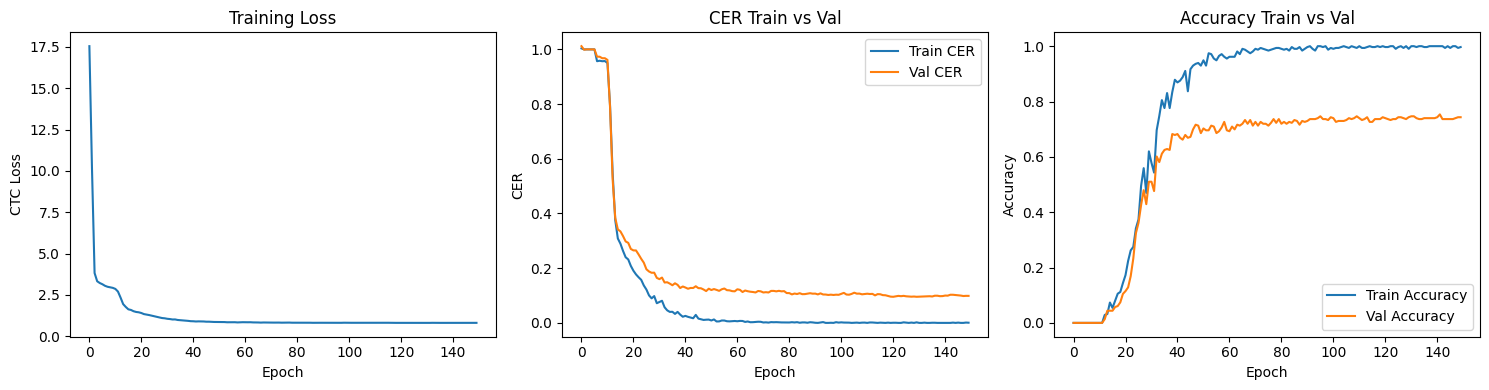

In [87]:
figure, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(train_losses)
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('CTC Loss')
ax[0].set_title('Training Loss')

ax[1].plot(train_cers, label='Train CER')
ax[1].plot(val_cers, label='Val CER')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('CER')
ax[1].set_title('CER Train vs Val')
ax[1].legend()

ax[2].plot(train_accs, label='Train Accuracy')
ax[2].plot(val_accs, label='Val Accuracy')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('Accuracy')
ax[2].set_title('Accuracy Train vs Val')
ax[2].legend()

plt.tight_layout()
plt.show()

## Save Final Predictions

In [88]:
checkpoint = torch.load(out_dir / 'best.pt', map_location=device)
model.load_state_dict(checkpoint['model_state'])

save_predictions(
    model, val_loader, device, inv_vocab,
    out_dir / 'test_predictions_final.csv'
)

print(f'Best Validation CER: {best_cer:.4f}')
print(f'Best Validation Accuracy: {max(val_accs):.4f}')

Predictions saved to runs\cnn_transformer_ctc\test_predictions_final.csv
Best Validation CER: 0.0954
Best Validation Accuracy: 0.7534


# Part 2  

## Error Analysis

We analyze the wrong predictions to understand what the model struggles with and decide what to improve.

From the wrong predictions we maybe notice that some characters are confused with each other such as B and 8, and some images are hard to read due to blur or low contrast. 
Based on this we propose some imporvments like : We remove any invalid characters from the prediction, add histogram equalization and threshold segmentation to improve image quality before feeding it to the model.


## Error Analysis

We look at where the model makes mistakes — which samples are hardest, and whether errors happen more in letters or digits.

### runs the trained model on every validation image and records three things for each one: the predicted text, the true text, and the CER score

In [89]:
# collect per-sample results on validation set
sample_preds = []
sample_gts = []
sample_cers = []

model.eval()
with torch.no_grad():
    for images, targets, target_lengths, gt_labels, paths in val_loader:
        images = images.to(device)
        logits = model(images)
        preds = ctc_greedy_decode_constrained(logits, inv_vocab)

        for pred, gt in zip(preds, gt_labels):
            cer_val = jiwer.cer(gt, pred)
            sample_preds.append(pred)
            sample_gts.append(gt)
            sample_cers.append(cer_val)

In [90]:
# sort by CER to find the hardest samples
sorted_indices = sorted(range(len(sample_cers)), key=lambda i: sample_cers[i], reverse=True)

print("Top 10 worst predictions:\n")
for i in sorted_indices[:10]:
    print(f"  True: {sample_gts[i]}   Predicted: {sample_preds[i]}   CER: {sample_cers[i]:.2f}")

Top 10 worst predictions:

  True: 683T   Predicted: 4341M   CER: 1.25
  True: 26996   Predicted: 71393H   CER: 1.00
  True: 6864BH   Predicted: 680980B   CER: 0.83
  True: 9148HK   Predicted: 249D   CER: 0.83
  True: 83656Y   Predicted: 53B   CER: 0.83
  True: 4905BY   Predicted: 38B   CER: 0.83
  True: 29060   Predicted: 4636M   CER: 0.80
  True: 8806AB   Predicted: 1066H   CER: 0.67
  True: 2599BK   Predicted: 589A   CER: 0.67
  True: 1205BM   Predicted: 39057A   CER: 0.67


### separates each prediction into two parts digits and letters and measures the CER for each part independently.

In [91]:
valid_letter_chars = set("ABDRSKM WYHLT")  # Omani plate letters

letter_cers = []
digit_cers = []

for gt, pred in zip(sample_gts, sample_preds):
    # extract only letters from gt and pred
    gt_letters = ""
    pred_letters = ""
    gt_digits = ""
    pred_digits = ""

    for ch in gt:
        if ch.isdigit():
            gt_digits += ch
        elif ch.upper() in valid_letter_chars:
            gt_letters += ch

    for ch in pred:
        if ch.isdigit():
            pred_digits += ch
        elif ch.upper() in valid_letter_chars:
            pred_letters += ch

    if len(gt_digits) > 0:
        digit_cers.append(jiwer.cer(gt_digits, pred_digits))

    if len(gt_letters) > 0:
        letter_cers.append(jiwer.cer(gt_letters, pred_letters))

avg_digit_cer = sum(digit_cers) / len(digit_cers)
avg_letter_cer = sum(letter_cers) / len(letter_cers)

print(f"Average Digit CER:  {avg_digit_cer:.4f}")
print(f"Average Letter CER: {avg_letter_cer:.4f}")

Average Digit CER:  0.0782
Average Letter CER: 0.1412


### finds every character the model got wrong and records what it predicted instead

In [92]:
# for each wrong character, record what was predicted
confusion = {}  # confusion[true_char] = list of predicted chars

for gt, pred in zip(sample_gts, sample_preds):
    # only compare when lengths match to keep it simple
    if len(gt) != len(pred):
        continue
    for t, p in zip(gt, pred):
        if t != p:
            if t not in confusion:
                confusion[t] = []
            confusion[t].append(p)

print("Character confusion (true → predicted):\n")
for true_char in sorted(confusion.keys()):
    preds_list = confusion[true_char]
    print(f"  '{true_char}' was predicted as: {preds_list}")

Character confusion (true → predicted):

  '0' was predicted as: ['T', '5', '3', 'M', '1']
  '1' was predicted as: ['3', '3', '3', '2', '3', '3']
  '2' was predicted as: ['0', '9', '9', '8', '9', '9', '4', '8']
  '3' was predicted as: ['2', '7', '2', '6', '2', '6']
  '4' was predicted as: ['2', '1']
  '5' was predicted as: ['3', '1']
  '6' was predicted as: ['5', '0', '9', '2', '5']
  '7' was predicted as: ['2', '2', '2']
  '8' was predicted as: ['0', '9', '9', '9']
  '9' was predicted as: ['3', '3', '3', '6', '6']
  'A' was predicted as: ['Y']
  'B' was predicted as: ['2', '7']
  'D' was predicted as: ['R', '6', 'R', 'R', '9']
  'H' was predicted as: ['Y', 'B', 'B']
  'M' was predicted as: ['0', 'A']
  'R' was predicted as: ['W', 'B']
  'S' was predicted as: ['B', 'B', 'H', 'B', '3']
  'T' was predicted as: ['B']
  'W' was predicted as: ['R', 'D']
  'Y' was predicted as: ['D', 'B', 'A']


### see some samples of wrong and predicted data 

Total wrong: 77



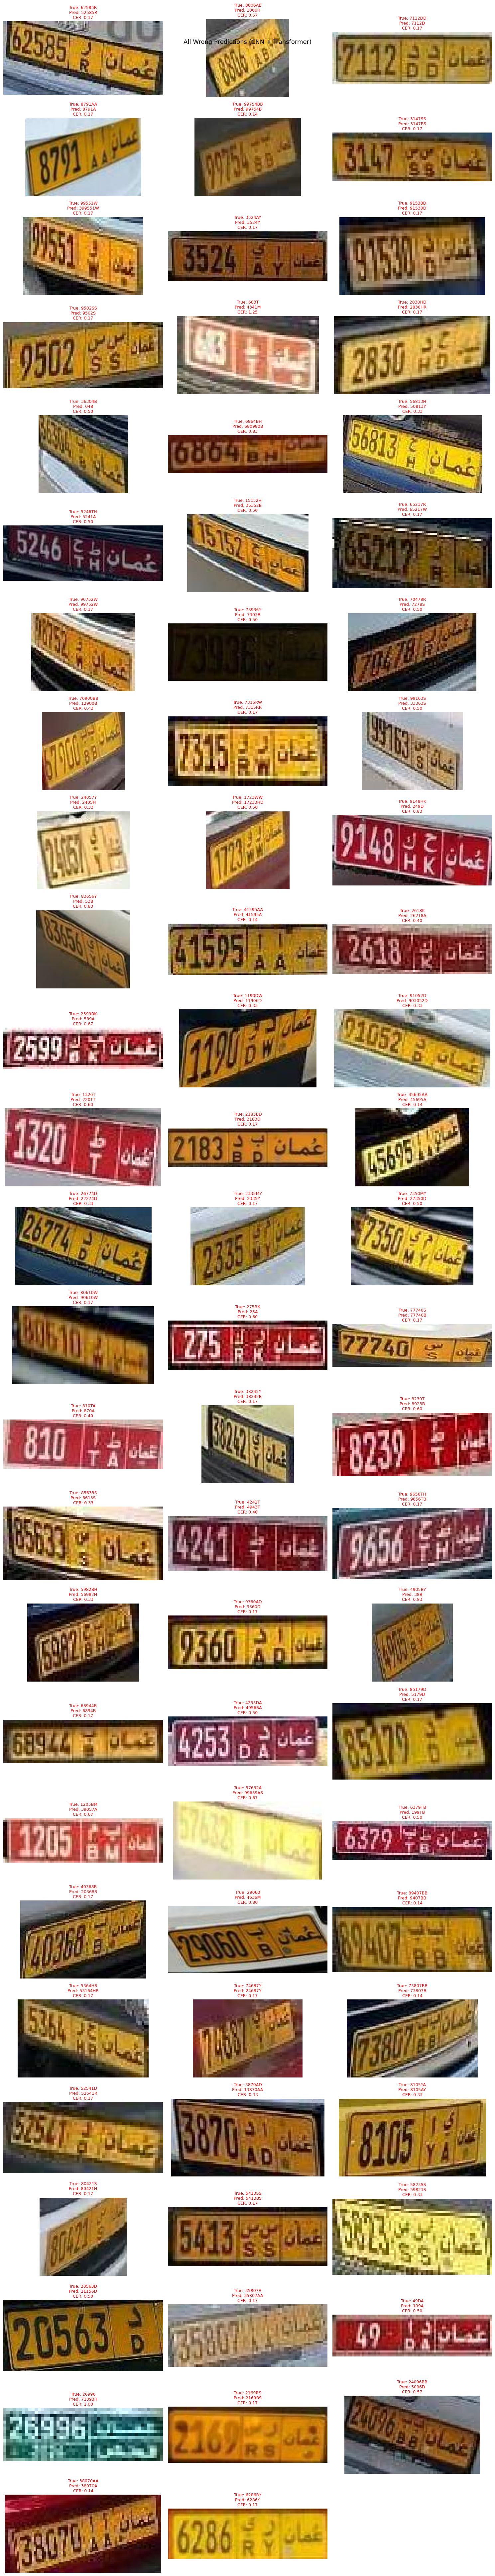

In [93]:
# show all wrong predictions with the actual plate image
wrong_samples = []
for i in range(len(sample_gts)):
    if sample_gts[i] != sample_preds[i]:
        wrong_samples.append(i)

print(f"Total wrong: {len(wrong_samples)}\n")

# plot each wrong sample with its image
cols = 3
rows = (len(wrong_samples) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
axes = axes.flatten()

wrong_idx = 0
for i, ax in enumerate(axes):
    if wrong_idx < len(wrong_samples):
        idx = wrong_samples[wrong_idx]

        gt = sample_gts[idx]
        pred = sample_preds[idx]
        cer_val = sample_cers[idx]

        img_path = f"test1/{gt}.jpg"
        img = Image.open(img_path)

        ax.imshow(img)
        ax.set_title(f"True: {gt}\nPred: {pred}\nCER: {cer_val:.2f}", fontsize=9, color="red")
        ax.axis("off")
        wrong_idx += 1
    else:
        ax.axis("off")

plt.suptitle("All Wrong Predictions (CNN + Transformer)", fontsize=13)
plt.tight_layout()
plt.show()


## Summary: Error Analysis and Improvements

After training the CNN + Transformer model we ran a detailed error analysis on the 101 validation images to understand where and why the model fails.

**Error Analysis Findings:**

The initial model had 14 wrong predictions with an average CER of 0.0345. Breaking this down by character type showed that letter CER (0.0737) was higher than digit CER (0.0447), which makes sense because plates only have 1-2 letters so one wrong letter has a bigger impact on CER. The character confusion table revealed 10 confused pairs, mostly visually similar characters such as R/Y, S/B, D/Y for letters and 2/7, 5/6 for digits. Visual inspection of the wrong predictions showed two failure types: images with poor lighting or dark edges where errors are understandable, and clear images where the model still failed due to CTC collapsing repeated characters (SS→S) or inserting a spurious digit at the plate boundary.

**Improvements Applied:**

1. **Constrained Decoding**: predictions are filtered to only include valid Omani plate characters and trimmed to a maximum length of 7, ensuring the output always looks like a valid Omani plate.

2. **Label Smoothing**: we added label smoothing (smoothing=0.1) to the CTC loss to stop the model from being overconfident on visually similar characters like 2/7 or R/Y. This mixes 90% CTC loss with 10% uniform penalty.

3. **Data Augmentation**: we added ColorJitter, RandomAffine, GaussianBlur, and RandomEqualize to the training transform to help the model handle dark and low-contrast plates.

4. **Number of Epochs**: we increased training from 100 to 150 epochs to allow the model more time to converge with the warmup and cosine decay schedule.

5. **Model Size Tuning**: we reduced the CNN backbone from 512 to 256 channels and the Transformer from 4 layers to 2 layers with d_model=256 and ffn_dim=512. This removed unnecessary parameters for a task with only 300 training images and 7-character outputs.

6. **Increase Data**: we increse number of data in the training set 



In [94]:
import csv
from pathlib import Path
from PIL import Image

# load best checkpoint
checkpoint = torch.load(out_dir / 'best.pt', map_location=device)
model.load_state_dict(checkpoint['model_state'])
model.eval()

testx_dir = Path('COMP4609_PROJECT_SUBMISSION_INSTRUCTIONS/COMP4609_PROJECT_SUBMISSION_INSTRUCTIONS/data/testx')
output_csv = out_dir / 'testx_predictions.csv'

rows = []
with torch.no_grad():
    for img_path in sorted(testx_dir.glob('*.jpg')):
        img = Image.open(img_path).convert('RGB')
        img_tensor = val_transform(img).unsqueeze(0).to(device)
        log_probs = model(img_tensor)
        pred = ctc_greedy_decode_constrained(log_probs, inv_vocab)[0]
        rows.append({'image_id': img_path.name, 'plate_text': pred})
        print(f"{img_path.name}  ->  {pred}")

with open(output_csv, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['image_id', 'plate_text'])
    writer.writeheader()
    writer.writerows(rows)

print(f'\nSaved {len(rows)} predictions to {output_csv}')

r1128wa.jpg  ->  20A
r1955th.jpg  ->  3955H
r348kb.jpg  ->  38B
r3710ym.jpg  ->  5309HA
r3808k.jpg  ->  3809
r3829wa.jpg  ->  999A
r4138ym.jpg  ->  638H
r4641hk.jpg  ->  408085Y
y101w.jpg  ->  101W
y1555ya.jpg  ->  1555AY
y2404a.jpg  ->  2404A
y2835a.jpg  ->  2835A
y3457a.jpg  ->  3457A
y3488rm.jpg  ->  3488MW
y3844as.jpg  ->  3844AA
y551mw.jpg  ->  551MW
y890s.jpg  ->  890S

Saved 17 predictions to runs\cnn_transformer_ctc\testx_predictions.csv
